In [1]:
print("Hello, World!")

Hello, World!


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
import numpy as np
from typing import List

c:\Users\Shradda\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


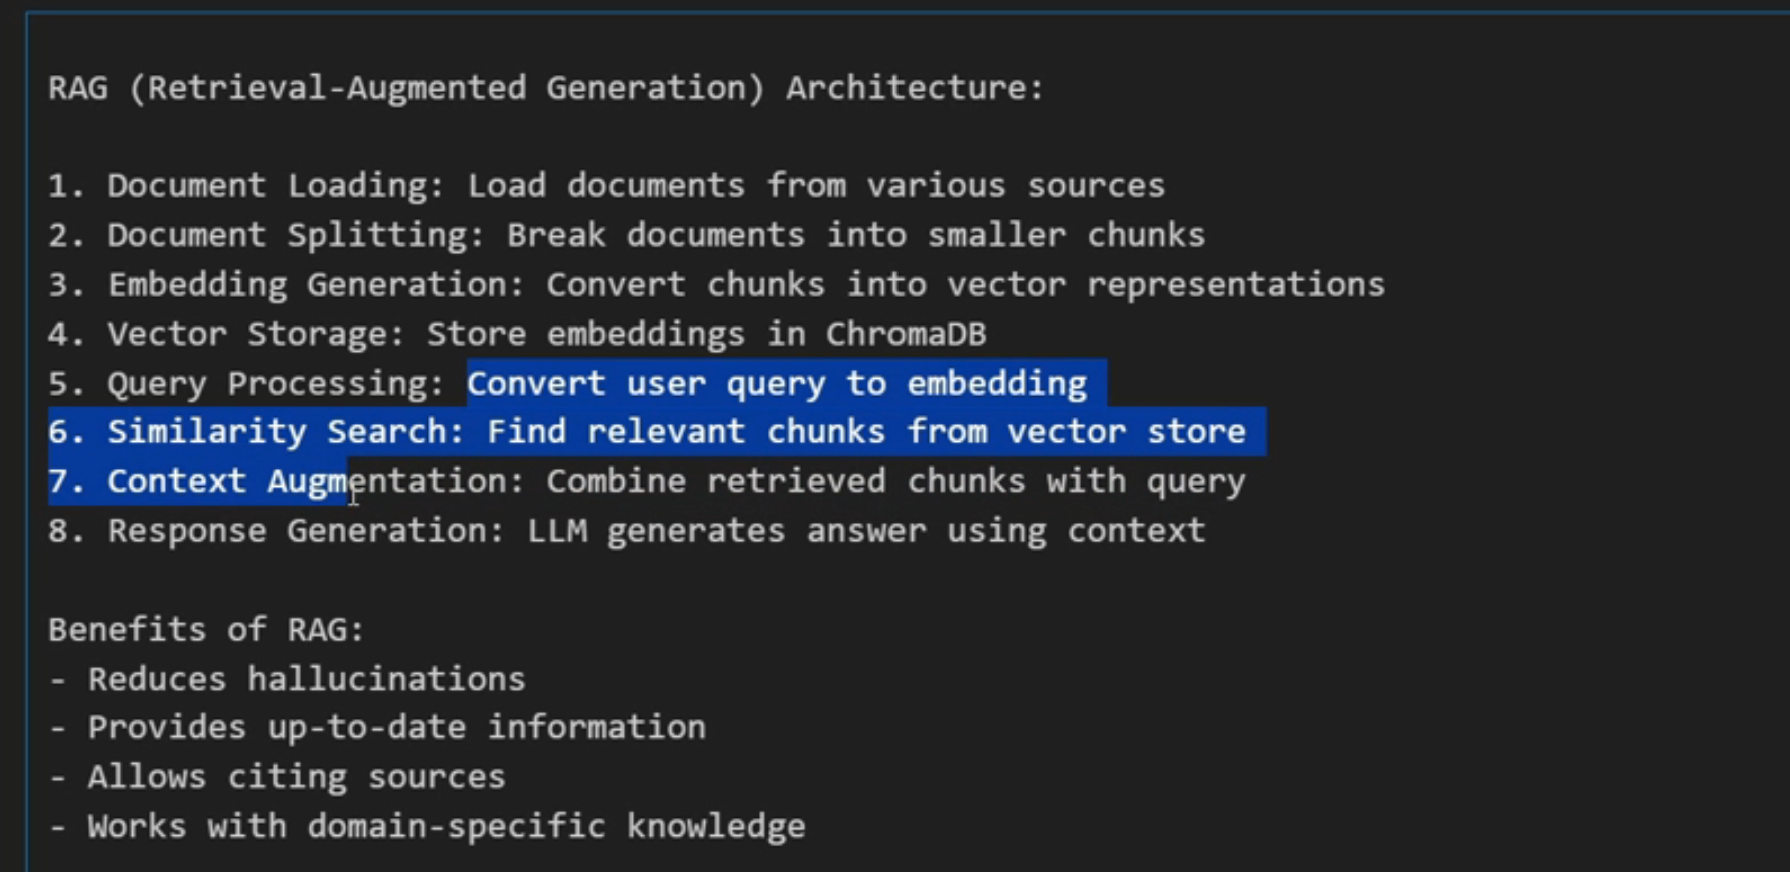

In [6]:
# Create some sample documents

sample_docs = [
    """
Machine Learning
Machine learning focuses on creating systems that learn patterns from data 
and use those patterns to make predictions or decisions. It relies on algorithms 
that adjust themselves as they see more examples, allowing models to improve performance over time.
""",
""" Deep Learning
Deep learning is a subset of machine learning that uses layered neural networks 
to learn complex patterns from large datasets. These networks automatically extract 
features and refine their internal representations as they process more data.    """,
"""  Natural Language Processing
Natural language processing applies machine learning and deep learning techniques 
to understand and generate human language. It learns patterns in text, captures 
meaning from data, and uses models to interpret or produce language-based outputs.   """]

In [7]:
sample_docs

['\nMachine Learning\nMachine learning focuses on creating systems that learn patterns from data \nand use those patterns to make predictions or decisions. It relies on algorithms \nthat adjust themselves as they see more examples, allowing models to improve performance over time.\n',
 ' Deep Learning\nDeep learning is a subset of machine learning that uses layered neural networks \nto learn complex patterns from large datasets. These networks automatically extract \nfeatures and refine their internal representations as they process more data.    ',
 '  Natural Language Processing\nNatural language processing applies machine learning and deep learning techniques \nto understand and generate human language. It learns patterns in text, captures \nmeaning from data, and uses models to interpret or produce language-based outputs.   ']

In [8]:
# Save the sample documents to text files
import tempfile
# temp_dir = tempfile.mkdtemp()
temp_dir = "data/"

for i, doc in enumerate(sample_docs):
    with open(f"{temp_dir}/doc_{i}.txt", "w") as f:
        f.write(doc)

print(f"Sample documents saved to: {temp_dir}")

Sample documents saved to: data/


In [9]:
import tempfile
temp_dir = tempfile.mkdtemp()

for i, doc in enumerate(sample_docs):
    with open(f"./data/doc_{i}.txt", "w") as f:
        f.write(doc)



# Document Loading

In [10]:
# Document Loading
from langchain_community.document_loaders import DirectoryLoader, TextLoader
loader = DirectoryLoader("./data/", glob="*.txt", show_progress=True)
documents = loader.load()
print(f"Loaded {len(documents)} documents.")
print(documents[0].page_content)


 33%|███▎      | 1/3 [00:01<00:03,  1.86s/it]libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
100%|██████████| 3/3 [00:01<00:00,  1.54it/s]

Loaded 3 documents.
Machine Learning Machine learning focuses on creating systems that learn patterns from data and use those patterns to make predictions or decisions. It relies on algorithms that adjust themselves as they see more examples, allowing models to improve performance over time.


In [11]:
documents

[Document(metadata={'source': 'data\\doc_0.txt'}, page_content='Machine Learning Machine learning focuses on creating systems that learn patterns from data and use those patterns to make predictions or decisions. It relies on algorithms that adjust themselves as they see more examples, allowing models to improve performance over time.'),
 Document(metadata={'source': 'data\\doc_1.txt'}, page_content='Deep Learning\n\nDeep learning is a subset of machine learning that uses layered neural networks\n\nto learn complex patterns from large datasets. These networks automatically extract\n\nfeatures and refine their internal representations as they process more data.'),
 Document(metadata={'source': 'data\\doc_2.txt'}, page_content='Natural Language Processing\n\nNatural language processing applies machine learning and deep learning techniques\n\nto understand and generate human language. It learns patterns in text, captures\n\nmeaning from data, and uses models to interpret or produce langua

In [12]:
## Document splitting
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20, length_function=len, separators=["\n\n", "\n", " ", ""])
split_docs = text_splitter.split_documents(documents)




In [13]:
split_docs

[Document(metadata={'source': 'data\\doc_0.txt'}, page_content='Machine Learning Machine learning focuses on creating systems that learn patterns from data and use'),
 Document(metadata={'source': 'data\\doc_0.txt'}, page_content='from data and use those patterns to make predictions or decisions. It relies on algorithms that'),
 Document(metadata={'source': 'data\\doc_0.txt'}, page_content='on algorithms that adjust themselves as they see more examples, allowing models to improve'),
 Document(metadata={'source': 'data\\doc_0.txt'}, page_content='models to improve performance over time.'),
 Document(metadata={'source': 'data\\doc_1.txt'}, page_content='Deep Learning\n\nDeep learning is a subset of machine learning that uses layered neural networks'),
 Document(metadata={'source': 'data\\doc_1.txt'}, page_content='to learn complex patterns from large datasets. These networks automatically extract'),
 Document(metadata={'source': 'data\\doc_1.txt'}, page_content='features and refine their

In [14]:
print(f"Split into {len(split_docs)} chunks from {len(documents)} documents.")
print("\n Sample chunk:")
print(split_docs[0].page_content)
print(f"Metadata: {split_docs[0].metadata}")

Split into 11 chunks from 3 documents.

 Sample chunk:
Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}


In [15]:
## Apply embedding model
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
from langchain_openai import OpenAIEmbeddings
openai_embedding = OpenAIEmbeddings(model="text-embedding-3-small", dimensions=1024)

In [16]:
sample_text = "Machine learning focuses on creating systems that learn patterns from data and use those patterns to make predictions or decisions."
embedding = openai_embedding.embed_query(sample_text)
print(f"Embedding vector (length {len(embedding)}):")
print(embedding)

Embedding vector (length 1024):
[-0.0160980224609375, -0.0021800994873046875, 0.050689697265625, -0.01448822021484375, 0.05584716796875, 0.01861572265625, 0.0240936279296875, 0.057037353515625, 0.005123138427734375, 0.06097412109375, -0.00740814208984375, 0.0037631988525390625, -0.03326416015625, -0.019073486328125, -0.005870819091796875, -0.0017023086547851562, -0.007656097412109375, 0.0185089111328125, 0.0268096923828125, -0.0094757080078125, 0.007434844970703125, 0.0192108154296875, 0.0672607421875, -0.00766754150390625, 0.033447265625, -0.0168304443359375, 0.0009975433349609375, 0.05963134765625, -0.0084075927734375, -0.0023174285888671875, 0.0205230712890625, -0.00031948089599609375, -0.0380859375, -0.0045013427734375, 0.0288238525390625, -0.034332275390625, -0.01971435546875, -0.0011758804321289062, -0.044036865234375, 0.045196533203125, -0.07037353515625, -0.010894775390625, 0.046600341796875, 0.06976318359375, -0.03692626953125, -0.0335693359375, -0.0140380859375, -0.0427246093

## Initalize ChromaDB vector store and store the chunks in vector representation

In [20]:
# Create Chroma vector store
persist_directory = "./chroma_db"

# Initialize Chroma vector store with OpenAI embedding model
vector_store = Chroma.from_documents(
    documents=split_docs,
    embedding=openai_embedding,
    persist_directory=persist_directory,
    collection_name="rag_collection"
)

print(f"Vector store created and persisted at: {persist_directory}")
print(f"Number of documents in vector store: {vector_store._collection.count()}")
print(f"Collection name: {vector_store._collection.name}")


Vector store created and persisted at: ./chroma_db
Number of documents in vector store: 44
Collection name: rag_collection


Test Similarity Search

In [21]:
## Test similarity search
query = "What are the types of machine learning?"
similar_docs = vector_store.similarity_search(query, k=3)
print("\nSimilar documents found:")
for i, doc in enumerate(similar_docs):
    print(f"\nDocument {i+1}:")
    print(doc.page_content)
    print(f"Metadata: {doc.metadata}")
    


Similar documents found:

Document 1:
Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}

Document 2:
Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}

Document 3:
Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}


In [22]:
query = "What is NLP?"
similar_docs_with_scores = vector_store.similarity_search_with_score(query, k=3)
print("\nSimilar documents with scores:")
for i, (doc, score) in enumerate(similar_docs_with_scores):
    print(f"\nDocument {i+1}:")
    print(doc.page_content)
    print(f"Metadata: {doc.metadata}")
    print(f"Similarity Score: {score:.2f}")


Similar documents with scores:

Document 1:
Natural Language Processing
Metadata: {'source': 'data\\doc_2.txt'}
Similarity Score: 0.64

Document 2:
Natural Language Processing
Metadata: {'source': 'data\\doc_2.txt'}
Similarity Score: 0.64

Document 3:
Natural Language Processing
Metadata: {'source': 'data\\doc_2.txt'}
Similarity Score: 0.64


In [23]:
## Advanced similarity search with scores
query = "How many types of crocodiles are there?"
similar_docs_with_scores = vector_store.similarity_search_with_score(query, k=3)
print("\nSimilar documents with scores:")
for i, (doc, score) in enumerate(similar_docs_with_scores):
    print(f"\nDocument {i+1}:")
    print(doc.page_content)
    print(f"Metadata: {doc.metadata}")
    print(f"Similarity Score: {score:.2f}")


Similar documents with scores:

Document 1:
on algorithms that adjust themselves as they see more examples, allowing models to improve
Metadata: {'source': 'data\\doc_0.txt'}
Similarity Score: 1.86

Document 2:
on algorithms that adjust themselves as they see more examples, allowing models to improve
Metadata: {'source': 'data\\doc_0.txt'}
Similarity Score: 1.86

Document 3:
on algorithms that adjust themselves as they see more examples, allowing models to improve
Metadata: {'source': 'data\\doc_0.txt'}
Similarity Score: 1.86


## Initialize LLM, RAG Chain, Prompt template, Query the RAG system

In [24]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.5, max_tokens=100)
query = "What are the types of machine learning?"
test_response = llm.invoke(query)
print("\nLLM Response:")    
print(test_response)


LLM Response:
content='1. Supervised learning\n2. Unsupervised learning\n3. Semi-supervised learning\n4. Reinforcement learning\n5. Transfer learning\n6. Deep learning\n7. Online learning\n8. Ensemble learning' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 15, 'total_tokens': 60, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EBBk4QDvUyqB7itrYj7uSdLJjPqWy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fe9e3-d875-7433-96ee-ff409f51fbc0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 45, 'total_tokens': 60, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

# Traditional RAG Chain

In [25]:
from langchain_classic.chains import create_retrieval_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

### Convert vector store to a retriever so that it can be used in a retrieval-based chain

In [26]:

retriever = vector_store.as_retriever(
search_kwargs={"k":3} ## Retriever will return top 3 similar documents for the query
)

retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000218C36D7950>, search_kwargs={'k': 3})

In [27]:

system_prompt = """You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.

Context: {context}
"""

In [28]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}")
    ]
)

In [23]:
prompt

ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\n\nContext: {context}\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])

In [29]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
document_chain = create_stuff_documents_chain(llm=llm, prompt=prompt)
document_chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\n\nContext: {context}\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])
| ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_

In [30]:
from langchain_classic.chains import create_retrieval_chain
retrieval_chain = create_retrieval_chain(retriever=retriever, combine_docs_chain=document_chain)

In [31]:
retrieval_chain

RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableBinding(bound=RunnableLambda(lambda x: x['input'])
           | VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000218C36D7950>, search_kwargs={'k': 3}), kwargs={}, config={'run_name': 'retrieve_documents'}, config_factories=[])
})
| RunnableAssign(mapper={
    answer: RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
              context: RunnableLambda(format_docs)
            }), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
            | ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf yo

In [32]:
response = retrieval_chain.invoke({"input": "What are the types of machine learning?"})


In [33]:
response

{'input': 'What are the types of machine learning?',
 'context': [Document(metadata={'source': 'data\\doc_0.txt'}, page_content='Machine Learning Machine learning focuses on creating systems that learn patterns from data and use'),
  Document(metadata={'source': 'data\\doc_0.txt'}, page_content='Machine Learning Machine learning focuses on creating systems that learn patterns from data and use'),
  Document(metadata={'source': 'data\\doc_0.txt'}, page_content='Machine Learning Machine learning focuses on creating systems that learn patterns from data and use')],
 'answer': 'The types of machine learning include supervised learning, unsupervised learning, and reinforcement learning. In supervised learning, the model is trained on labeled data. Unsupervised learning involves training on unlabeled data to find hidden patterns. Reinforcement learning is about training models to make a sequence of decisions to achieve a goal.'}

In [34]:
response['answer']

'The types of machine learning include supervised learning, unsupervised learning, and reinforcement learning. In supervised learning, the model is trained on labeled data. Unsupervised learning involves training on unlabeled data to find hidden patterns. Reinforcement learning is about training models to make a sequence of decisions to achieve a goal.'

Create RAG chain using LCEL (Langchain Expression Language)

In [35]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel



In [36]:
custom_prompt = ChatPromptTemplate.from_template(""" Use the following context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Context: {context}

Question: {question}

Answer: """)

In [37]:
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

In [42]:
## Build the chain using LCEL
rag_chain_lcel = (
    {
        "context": retriever | format_docs, 
        "question": RunnablePassthrough()
    }
    | custom_prompt
    | llm
    | StrOutputParser()
)


In [39]:
rag_chain_lcel

{
  context: VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000218C36D7950>, search_kwargs={'k': 3})
           | RunnableLambda(format_docs),
  question: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template=" Use the following context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nContext: {context}\n\nQuestion: {question}\n\nAnswer: "), additional_kwargs={})])
| ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inpu

In [40]:
response = rag_chain_lcel.invoke("What are the types of machine learning?")
print("\nRAG Chain Response:")
print(response)



RAG Chain Response:
The types of machine learning are supervised learning, unsupervised learning, and reinforcement learning.


In [41]:
docs = retriever.invoke("What are the types of machine learning?")
print("\Source Documents:")
for i, doc in enumerate(docs):
    print(f"\Source {i+1}:")
    print(f"- {doc.page_content}")
    print(f"Metadata: {doc.metadata}")

<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\Shradda\AppData\Local\Temp\ipykernel_10824\1105228779.py:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  print("\Source Documents:")
C:\Users\Shradda\AppData\Local\Temp\ipykernel_10824\1105228779.py:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will no

\Source Documents:
\Source 1:
- Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}
\Source 2:
- Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}
\Source 3:
- Machine Learning Machine learning focuses on creating systems that learn patterns from data and use
Metadata: {'source': 'data\\doc_0.txt'}


## Add New docs to existing vector store

In [43]:
vector_store

In [46]:
new_document = """

Reinforcement Learning:
Reinforcement learning is a type of machine learning where an agent learns by interacting with an environment and receiving feedback as rewards or penalties. 
The agent chooses actions to maximize cumulative reward over time, discovering which behaviors lead to better outcomes. It is commonly used in robotics, games, and decision-making systems where trial-and-error learning is effective. The core idea is balancing exploration of new actions with exploitation of known good strategies. Over repeated episodes, the agent improves its policy to make smarter decisions in similar situations.

"""

In [47]:
new_document

'\n\nReinforcement Learning:\nReinforcement learning is a type of machine learning where an agent learns by interacting with an environment and receiving feedback as rewards or penalties. \nThe agent chooses actions to maximize cumulative reward over time, discovering which behaviors lead to better outcomes. It is commonly used in robotics, games, and decision-making systems where trial-and-error learning is effective. The core idea is balancing exploration of new actions with exploitation of known good strategies. Over repeated episodes, the agent improves its policy to make smarter decisions in similar situations.\n\n'

In [48]:
new_document = Document(page_content=new_document, metadata={"source": "manual addition of a new document", 
                                                             "topic": "Reinforcement Learning"})

In [49]:
new_document

Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='\n\nReinforcement Learning:\nReinforcement learning is a type of machine learning where an agent learns by interacting with an environment and receiving feedback as rewards or penalties. \nThe agent chooses actions to maximize cumulative reward over time, discovering which behaviors lead to better outcomes. It is commonly used in robotics, games, and decision-making systems where trial-and-error learning is effective. The core idea is balancing exploration of new actions with exploitation of known good strategies. Over repeated episodes, the agent improves its policy to make smarter decisions in similar situations.\n\n')

### Add thsi to vector store

In [50]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20, length_function=len, separators=["\n\n", "\n", " ", ""])
new_split_docs = text_splitter.split_documents([new_document])

In [51]:
new_split_docs

[Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='Reinforcement Learning:'),
 Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='Reinforcement learning is a type of machine learning where an agent learns by interacting with an'),
 Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='interacting with an environment and receiving feedback as rewards or penalties.'),
 Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='The agent chooses actions to maximize cumulative reward over time, discovering which behaviors lead'),
 Document(metadata={'source': 'manual addition of a new document', 'topic': 'Reinforcement Learning'}, page_content='behaviors lead to better outcomes. It is commonly used in robotics, games, and decision-making'),
 Do

In [52]:
vector_store.add_documents(new_split_docs)

['528155ff-7866-4144-a7c5-abc9f13fc2b8',
 'd7e55a83-3546-4ad2-bbb2-80477e7cb5ab',
 '4f5fb25f-763a-48f1-aea3-b0839c496c08',
 '99affa07-c6f2-407c-af7d-43043ef48c8e',
 '9db81779-ace1-432a-a05b-8f1383d7e755',
 '0a870f0e-7704-4e79-86c0-13b3cb52a5ed',
 '60460652-e716-4b62-a6ae-257ae1d14d32',
 '9b721418-b3a2-4fdb-b9b4-ab21ef081f53',
 'b72cb5cc-f515-4cc2-9ce5-1542a3021d80']

In [53]:
print(f"New document added to vector store. Total documents now: {vector_store._collection.count()}")

New document added to vector store. Total documents now: 53


In [55]:
new_question = "What are the key concepts in reinforcement learning?"
new_result = rag_chain_lcel.invoke(new_question)

In [56]:
new_result

'The key concepts in reinforcement learning are agent, environment, and rewards.'

## Advanced RAG Technique - Conversational Memory

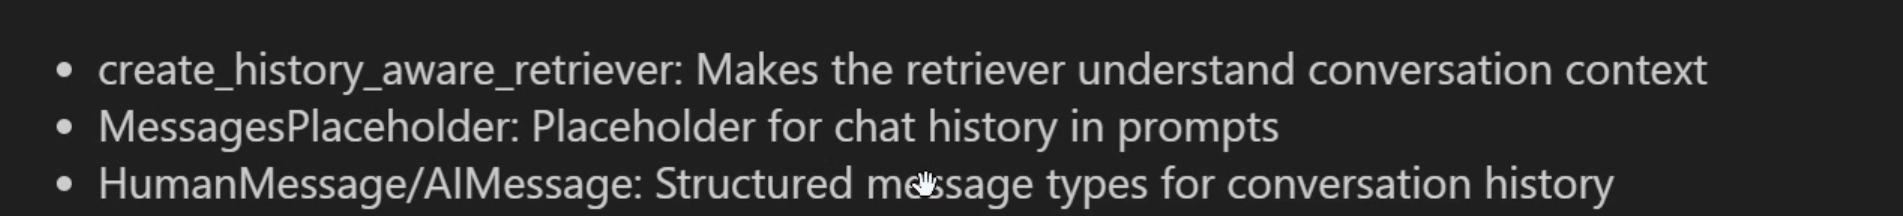

In [60]:
from langchain_classic.chains import create_history_aware_retriever
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

In [61]:
contextualize_q_system_prompt = """Given a chat history and the latest user question which might
reference context from the history, provide a reformulated question which could be understood without the chat history. 

Do not answer the question, just reformulate it. If the question is already clear, return it as is."""



In [62]:
contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}")
    ]
)

In [65]:
history_aware_retriever = create_history_aware_retriever(
    llm,
    retriever,
    contextualize_q_prompt
)

In [66]:
history_aware_retriever

RunnableBinding(bound=RunnableBranch(branches=[(RunnableLambda(lambda x: not x.get('chat_history', False)), RunnableLambda(lambda x: x['input'])
| VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000218C36D7950>, search_kwargs={'k': 3}))], default=ChatPromptTemplate(input_variables=['chat_history', 'input'], input_types={'chat_history': list[typing.Annotated[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')] | typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')] | typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')] | typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')] | typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')] | typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')] | typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMe

In [67]:
qa_system_prompt = """ You are an assistant for the question answerring tasks.
Use the following chat history to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Context: {context}"""

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", qa_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}")
    ]
)

question_answer_chain = create_stuff_documents_chain(llm=llm, prompt=qa_prompt)

In [68]:
conversational_rag_chain = create_retrieval_chain(history_aware_retriever, question_answer_chain)  

In [70]:
chat_history = []
result1 = conversational_rag_chain.invoke({
    "chat_history": chat_history,
    "input": "What are the types of machine learning?"})
print(f"Q:  What is reinforcement learning?\nA: {result1['answer']}")

Q:  What is reinforcement learning?
A: The types of machine learning are supervised learning, unsupervised learning, and reinforcement learning. Each type involves different approaches to learning patterns from data and making predictions or decisions based on that learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through trial and error interactions with an environment.


In [71]:
chat_history

[]

In [73]:
chat_history.extend([
    HumanMessage(content="What are the types of machine learning?"),
    AIMessage(content=result1['answer'])
])

In [74]:
chat_history

[HumanMessage(content='What are the types of machine learning?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='The types of machine learning are supervised learning, unsupervised learning, and reinforcement learning. Each type involves different approaches to learning patterns from data and making predictions or decisions based on that learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through trial and error interactions with an environment.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

#Follow up question

In [75]:
result2 = conversational_rag_chain.invoke({
    "chat_history": chat_history,
    "input": "What are its main types?"})
print(f"Q:  What is reinforcement learning?\nA: {result2['answer']}")

Q:  What is reinforcement learning?
A: The main types of machine learning are supervised learning, unsupervised learning, and reinforcement learning. Each type has its own approach to learning patterns from data and making predictions or decisions based on that learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through trial and error interactions with an environment.
